In [55]:
import os
import glob
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from vip_slap2_analysis.plotting import (
    MovieRenderConfig,
    inspect_tiff_layout,
    render_glutamate_df_movie,
    load_slap2_movie_from_tiffs
)
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary

In [56]:
%matplotlib notebook

In [57]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [120]:
def display_meanim(exp, dmd=1, image_type="meanIM", channel=0, robust=(1, 99)):
    im = exp.get_summary_image(dmd=dmd, image_type=image_type)
    if im.shape[1]>im.shape[0]:
        im = im.T

    if im.ndim == 3:
        if channel >= im.shape[1]:
            raise ValueError(f"Requested channel {channel}, but image has shape {im.shape}")
        im = im[:, channel, :]
    elif im.ndim != 2:
        raise ValueError(f"Unexpected meanIM shape: {im.shape}")

    im = np.nan_to_num(im, nan=0.0)
    vmin, vmax = np.percentile(im, robust)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(im.T, cmap="viridis", vmin=vmin, vmax=vmax, origin="lower")
    ax.set_title(f"DMD{dmd} {image_type}, channel {channel}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    return fig, ax

In [122]:
BASE_PATH = Path(r"\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics")
SESSION_ID = None  # e.g. "834788_2026-03-04_08-43-07"; leave as None to use SUBJECT_ID + SESSION_INDEX
SUBJECT_ID = 810196
SESSION_INDEX = 4  # used only when SESSION_ID is None

FS_HZ = 200.0
DMD_FOR_CALCIUM = 2
ROI_INDICES_TO_PLOT = [0,1,2]          # whole-session calcium traces
MAX_SESSION_MINUTES = None         # e.g. 10.0 to truncate late-session data
MOTION_CORRECT = True
TRACE_TYPE = "Fsvd"
CALCIUM_TRACE_KEY = "dff"         # one of: dff, ca_mc, ca_unmixed, ca_clean

DMD_FOR_MEANIM = 1
MEANIM_IMAGE_TYPE = "meanIM"
MEANIM_CHANNEL = 0

In [123]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

if SESSION_ID is not None:
    session_row = registry.get_session_row(SESSION_ID)
else:
    subject_sessions = registry.sessions(subject_ids=[SUBJECT_ID]).reset_index(drop=True)
    if len(subject_sessions) == 0:
        raise ValueError(f"No sessions found for subject {SUBJECT_ID}")
    session_row = subject_sessions.iloc[SESSION_INDEX]

asset = registry.resolve_assets(session_row)
asset.ensure_dirs()
exp = GlutamateSummary(asset.summary_mat, keep_open=True)

print(f"session_id: {asset.session_id}")
print(f"subject_id: {asset.subject_id}")
print(f"summary_mat: {asset.summary_mat}")
print(f"bonsai_csv: {asset.bonsai_event_log_csv}")
print(f"qc_dir: {asset.qc_dir}")
print(f"derived_dir: {asset.derived_dir}")

session_id: 810196_2025-07-31_08-28-08
subject_id: 810196
summary_mat: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-30_810196\810196_2025-07-31_08-28-08_slap2_2026-01-16_17-12-16\source_extraction\ExperimentSummary\SummaryLoCo-260116-091428.mat
bonsai_csv: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-30_810196\810196_2025-07-31_08-28-08\behavior\VCO1_Behavior.harp\bonsai_event_log.csv
qc_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-30_810196\analysis\qc
derived_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-30_810196\analysis\derived


<IPython.core.display.Javascript object>


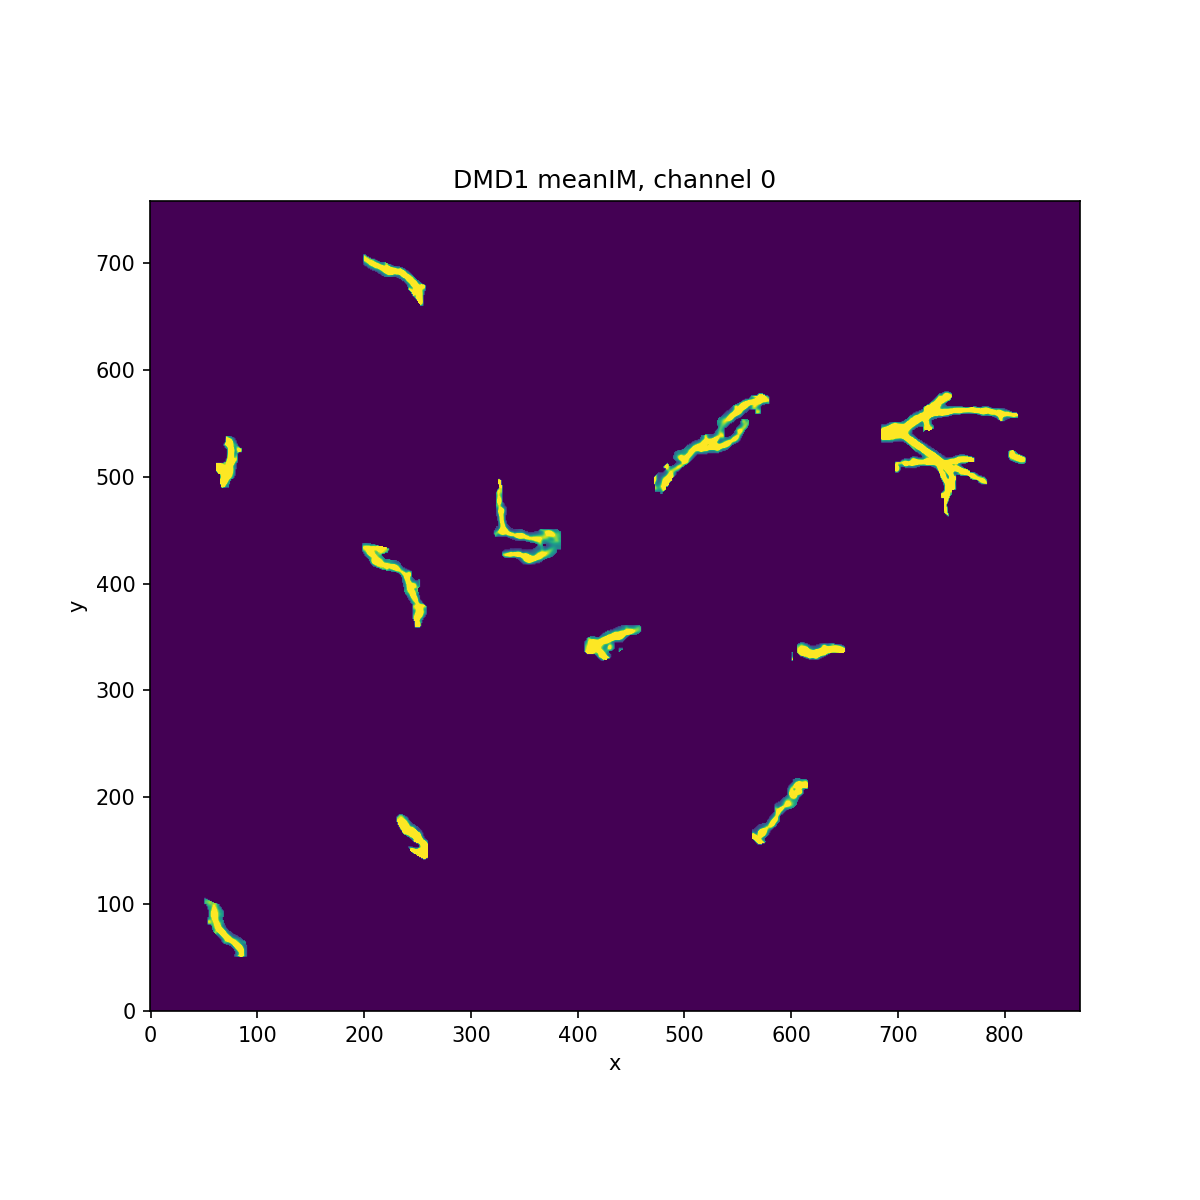

In [124]:
fig, ax = display_meanim(
    exp,
    dmd=DMD_FOR_MEANIM,
    image_type=MEANIM_IMAGE_TYPE,
    channel=MEANIM_CHANNEL,
)

In [125]:
cfg = MovieRenderConfig(
    input_frame_rate_hz=80.0,
    output_frame_rate_hz=20.0,
    downsample_factor_time=0,
    baseline_window_s=0.35,
    baseline_mode="fast",
    channel_index=0,
    activity_percentile=99.995,
    structure_percentile=99.9,
    gamma=0.75,
    transpose_xy=True,
    show_timer=True,
    show_scale_bar=True,
    pixel_size_um=0.25,
    scale_bar_um=20.0,
    overlay_fontsize=16,
    overlay_linewidth=4,
)

In [126]:
asset.session_dir

WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f/810196/2025-07-30_810196')

In [127]:
trial = 12

dmd1_path = glob.glob(os.path.join(asset.session_dir,'**',
                                   f'E1T{trial}DMD1_REGISTERED_DOWNSAMPLED-80Hz.tif'),
                      recursive=True)[0]

# dmd2_path = glob.glob(os.path.join(asset.session_dir,'**',
#                                    f'E1T{trial}DMD2_REGISTERED_DOWNSAMPLED-80Hz.tif'),
#                       recursive=True)[0]

In [128]:
inspect_tiff_layout(dmd1_path)

path: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-30_810196\810196_2025-07-31_08-28-08\slap2\dynamic_data\E1T12DMD1_REGISTERED_DOWNSAMPLED-80Hz.tif
series count: 1
series 0: shape=(749, 931, 819), axes=IYX
pages: 749
memmap shape: (749, 931, 819) dtype: float32


In [129]:
dmd = 1

output_path = os.path.join(asset.session_dir,f"dmd{dmd}_trial{trial}.mp4")

In [131]:
render_glutamate_df_movie(
    output_path=output_path,
    config=cfg,
    dmd1_tiff=dmd1_path,
    dmd_selection=f"dmd{dmd}",
    #     crop_bbox=(225, 400, 525, 696),
    n_channels=1,
    start_s=0,
    end_s=9,
    overwrite=True,
    verbose=True,
)

[###---------------------] 1/8  Loading movie subset
Opening TIFF: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\iGluSnFR4f\810196\2025-07-30_810196\810196_2025-07-31_08-28-08\slap2\dynamic_data\E1T12DMD1_REGISTERED_DOWNSAMPLED-80Hz.tif
Opened as memmap with shape=(749, 931, 819), dtype=float32
Loading frames [0:720] -> pages [0:720] from total 749 frames with 1 channel(s)
Loaded subset shape: (931, 819, 1, 720)
[######------------------] 2/8  Selecting channel / standardizing shape
Movie shape after channel selection: (931, 819, 720)
[#########---------------] 3/8  Time window already applied during load
Movie shape after time selection: (931, 819, 720)
[############------------] 4/8  Applying orientation transform
Movie shape after orientation transform: (819, 931, 720)
[###############---------] 5/8  Cropping in display space if needed
Movie shape after crop: (819, 931, 720)
[##################------] 6/8  Temporal downsampling
Movie shape after downsampling: (819, 931, 72

WindowsPath('//allen/aind/scratch/ophys/Andrew/VIP_synaptic_dynamics/iGluSnFR4f/810196/2025-07-30_810196/dmd1_trial12.mp4')